In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

az.style.use('arviz-darkgrid')
plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


# Bayesian Model Evaluation

In the "Model Evaluation" notebook, we judged the model performances by measuring the distance of their predictions from the ground truth. We cannot do this in the Bayesian world since predictions are denoted as a distribution, not a point estimate.

In this notebook we will see how to draw insights from the posterior distributions so we can select the model.

## The Measure

If we have a model trained on data $(X,y)$, we obtain a posterior distribution for the parameters:

$(X,y) \rightarrow p(\theta \mid y)$

Suppose a new observation $\tilde{y}$ arrives.

So the probability value will be (assume normally distributed)

$p(\tilde{y} \mid \tilde{x},\theta^{(s)}) = \mathcal{N}(\beta_0^{(s)} + \beta_1^{(s)}\tilde{x},\ \sigma^{(s)}) \quad (1)$

Equation $(1)$ gives us one density per posterior draw. So for example, a posterior with $4000$ draws leaves us with $4000$ different curves. To end up with a single predictive distribution we average them and find an expected distribution. Since the posterior is already stored as a collection of draws (in other words it is discrete), we can find the expected distribution via:

$p(\tilde{y} \mid \tilde{x},X,y) \approx \frac{1}{S}\sum_{s=1}^{S} p(\tilde{y} \mid \tilde{x},\theta^{(s)}) \quad (2)$

The posterior predictive distribution is written in short as $p(\tilde{y} \mid y)$.

During the evaluation, we often need to consider more than one observation. To convert multiplication operations to addition, again we translate the posterior probabilities into the log scale.

**Example**

We will reuse the dataset from the "Bayesian Linear Regression" notebook, where we introduced a couple of anomaly data points.

$X_{\text{normal}} \sim \mathcal{N}(5,1^2)$

$y_{\text{normal}} = 2X_{\text{normal}} + \epsilon$

$X_{\text{outlier}} = \{15,16,17\}$

$y_{\text{outlier}} = 4X_{\text{outlier}} + 20$

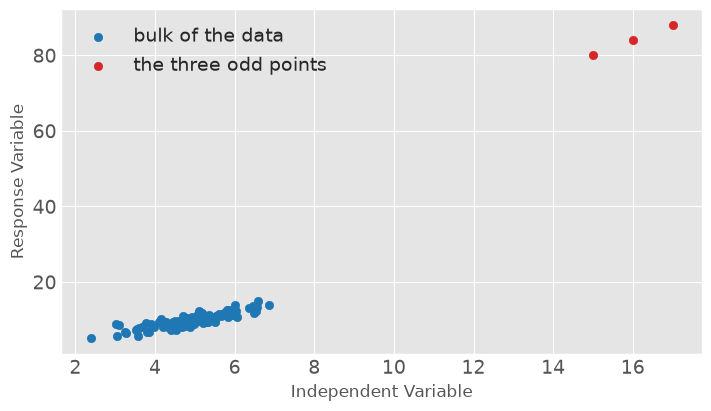

In [2]:
np.random.seed(42)

X = np.random.normal(loc = 5, scale = 1, size = 100)
error = np.random.normal(loc = 0, scale = 1, size = 100)
y = 2*X + error

outlier_X = np.array([15, 16, 17])
outlier_y = outlier_X * 4 + 20

X = np.concatenate((X, outlier_X))
y = np.concatenate((y, outlier_y))

df = pd.DataFrame({"Independent_Variable": X, "Response_Variable": y})

fig, ax = plt.subplots(figsize = (7, 4))
ax.scatter(X[:100], y[:100], color = 'tab:blue', label = 'bulk of the data')
ax.scatter(X[100:], y[100:], color = 'tab:red', label = 'the three odd points')
ax.set_xlabel('Independent Variable')
ax.set_ylabel('Response Variable')
ax.legend()
plt.show()

Also, we will use the same models for evaluation.

In [3]:
common_priors = {
    "Intercept": bmb.Prior("Normal", mu = 0, sigma = 5),
    "Independent_Variable": bmb.Prior("Flat"),
    "sigma": bmb.Prior("HalfCauchy", beta = 3)
}

normal_model = bmb.Model("Response_Variable ~ Independent_Variable",
                         data = df,
                         priors = common_priors)

normal_fit = normal_model.fit(random_seed = 42,
                              idata_kwargs = {"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Independent_Variable]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [4]:
t_priors = dict(common_priors)
t_priors["nu"] = bmb.Prior("Exponential", lam = 1)

t_model = bmb.Model("Response_Variable ~ Independent_Variable",
                    data = df,
                    family = "t",
                    priors = t_priors)

t_fit = t_model.fit(random_seed = 42,
                    idata_kwargs = {"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, nu, Intercept, Independent_Variable]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


## Leave One Out Cross Validation

In traditional LOOCV, we exclude a single data point from the dataset and fit the model to the rest. Repeating the same process for a Bayesian model is not a good idea since Bayesian models require more time and resources to fit. Instead, we can remove the contribution of a single data point to the posterior distribution sequentially. The reliability of this removal is measured by a diagnostic called the Pareto $k$. Typically, a value above $0.7$ means the approximation is not trustworthy for that data point, which happens when the point is influential enough to move the posterior once it is excluded.

The good thing about the Pareto $k$ approach is that it allows us to see which data points are fitted particularly poorly by the model.


In [5]:
normal_loo = az.loo(normal_fit, pointwise = True)
normal_loo

Computed from 4000 posterior samples and 103 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -295.08     9.25
p_loo        7.78        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      100   97.1%
   (0.70, 1]   (bad)         3    2.9%
    (1, Inf)   (very bad)    0    0.0%

In [6]:
t_loo = az.loo(t_fit, pointwise = True)
t_loo

Computed from 4000 posterior samples and 103 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -185.43    18.72
p_loo        5.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      103  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%

The fat tails of the Student t distribution prevented the contribution of the outlier data points from being excessive, hence none of the points exceeded the $0.7$ threshold. On the other hand, the normal model indicates that there are $3$ data points that are a particularly bad fit (or change the posterior distribution significantly). However, it does not tell exactly which data points they are. To find those data points, we can filter the data points having a Pareto $k$ greater than $0.7$.

In [7]:
normal_k = normal_loo.pareto_k.values.flatten()
t_k = t_loo.pareto_k.values.flatten()

print("Normal model, observations with k > 0.7:", np.where(normal_k > 0.7)[0])
print("Student t model, observations with k > 0.7:", np.where(t_k > 0.7)[0])

Normal model, observations with k > 0.7: [100 101 102]
Student t model, observations with k > 0.7: []


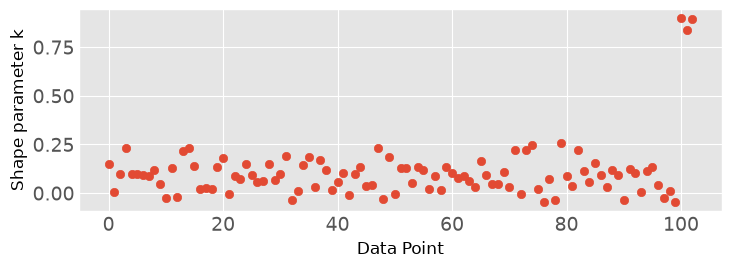

In [8]:
azp.plot_khat(normal_loo)

So the last $3$ data points in the dataset are a bad fit. Since we generated the dataset, we can verify this easily. On the other hand, in real case scenarios the Pareto $k$ diagnostic can be really useful.

## Comparing Models Side by Side

In [9]:
comparison = az.compare({"normal": normal_fit, "student_t": t_fit})
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
student_t,0,0.0,0.0,NaN,,,5.7,-190.0,19.0,0.96
normal,1,-110.0,14.0,1.0,,3 k̂ > 0.70,7.8,-300.0,9.2,0.04


The table is worth discussing.

**ELPD** stands for Expected Log Pointwise Predictive Density. Ideally we want the posterior predictive density of each hold out data point to remain high. So in order to evaluate the performance of a model, we sum all log posterior densities. The higher the better. In this case, the student_t model works better. The posterior predictive density of the outlier points is lower compared to the normal model, but the density of the remaining $100$ data points is much higher, and that gain outweighs the loss.

**SE** stands for the standard error of the elpd estimate, which reflects how much the log posterior densities vary between the data points. The normal model is pulled towards the outlier data points and inflates its $\sigma$ (remember the regression plot in the "Bayesian Linear Regression" notebook). A wide $\sigma$ assigns similar densities to every data point, which results in a decrease in standard error. On the flip side, the student t model is robust to these outliers and keeps its $\sigma$ small, hence the densities vary a lot and the standard error remains high.

**Weight** emphasizes a different topic. If there is a prediction to be made, it answers what the ideal combination of the model predictions is. In this case, the normal model is worse, therefore its weight is lower.

**diag_elpd** shows the number of data points exceeding the Pareto $k$ threshold. It helps us to understand the reliability of each model.

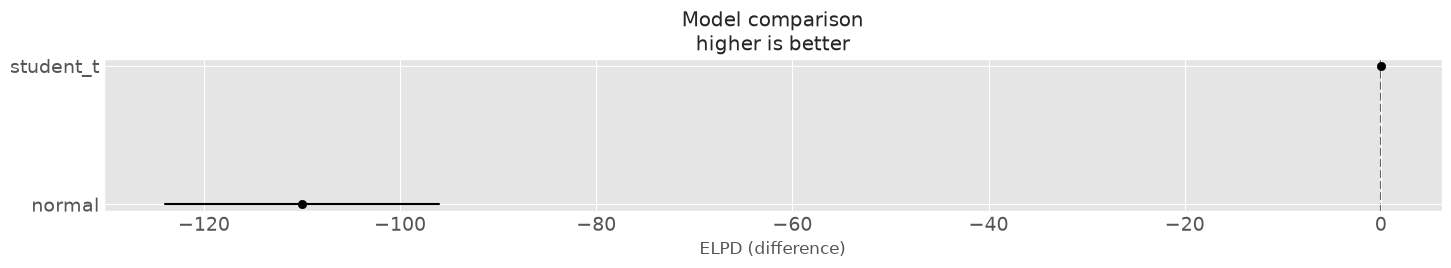

: 

In [ ]:
azp.plot_compare(comparison)

From the plot we can see that the normal model has a lower ELPD, and the difference lies in the $[-124,-96]$ range.

In conclusion, in this notebook we evaluated and compared different Bayesian models. Since the student t model is more robust to the outliers, it fits the data better.

In the next notebook we will continue with a different topic which cannot be replicated in the frequentist world. The Bayesian Update.